# Third Autocorrelation Inequality — Analysis & Verification

This notebook verifies and visualizes our solution for the third autocorrelation inequality.

**Problem:** Find a function $f$ (**may be negative**) that minimizes
$$C_3 = \frac{\bigl|\max_t\; f \star f(t)\bigr|}{\bigl(\int f\bigr)^2}$$
where $f \star f$ is the autoconvolution. Unlike the first autocorrelation problem, $f$ is not restricted to be non-negative.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys

sys.path.insert(0, 'solutions')

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

## 1. Verification Function

The verifier computes:
1. $dx = 0.5 / n$
2. Autoconvolution $g = \mathrm{convolve}(f, f) \cdot dx$
3. $C_3 = |\max(g)| \;/\; (\sum f \cdot dx)^2$

The function $f$ may take negative values, but $\int f$ must be non-zero.

In [2]:
def verify_and_compute_c3(values):
    """Exact EinsteinArena verifier for the third autocorrelation inequality."""
    f = np.array(values, dtype=np.float64)
    n_points = len(values)
    dx = 0.5 / n_points
    integral_f_sq = (np.sum(f) * dx) ** 2
    if integral_f_sq < 1e-9:
        raise ValueError("Function integral is close to zero, ratio is unstable.")
    conv = np.convolve(f, f, mode="full")
    scaled_conv = conv * dx
    max_conv = abs(np.max(scaled_conv))
    return float(max_conv / integral_f_sq)

## 2. Load Solution

In [3]:
from alphaevolve_2025 import f_values as ae_values
from ours_2026 import f_values as our_values

solutions = [
    ("AlphaEvolve (2025)", ae_values),
    ("Together AI (2026)", our_values),
]

for name, vals in solutions:
    f = np.array(vals, dtype=np.float64)
    print(f'{name}: {len(f)} points, range [{f.min():.4f}, {f.max():.4f}], '
          f'negative: {np.sum(f < 0)}/{len(f)}')

AlphaEvolve (2025): 400 points, range [-0.7397, 1.2065], negative: 86/400
Together AI (2026): 400 points, range [-21.7626, 29.8225], negative: 73/400


## 3. Verify Score

In [4]:
print("=" * 70)
print("VERIFICATION OF ALL SOLUTIONS")
print("=" * 70)
print()

scores = {}
for name, vals in solutions:
    score = verify_and_compute_c3(vals.tolist())
    scores[name] = score
    print(f'{name}')
    print(f'  Points: {len(vals)}')
    print(f'  Score:  C_3 <= {score:.15f}')
    print()

print("=" * 70)
print("COMPARISON TABLE")
print("=" * 70)
print(f"{'Method':<35} {'Points':>8} {'Upper Bound':>18}")
print("-" * 63)
print(f"{'AC1 non-negative (reference)':<35} {'30,000':>8} {'1.502863':>18}")
for name, vals in solutions:
    marker = "  <-- NEW SOTA" if name == "Ours (2026)" else ""
    print(f"{name:<35} {len(vals):>8} {scores[name]:>18.6f}{marker}")

VERIFICATION OF ALL SOLUTIONS

AlphaEvolve (2025)
  Points: 400
  Score:  C_3 <= 1.455642795374540

Together AI (2026)
  Points: 400
  Score:  C_3 <= 1.454554862698333

COMPARISON TABLE
Method                                Points        Upper Bound
---------------------------------------------------------------
AC1 non-negative (reference)          30,000           1.502863
AlphaEvolve (2025)                       400           1.455643
Together AI (2026)                       400           1.454555


## 4. Visualization

Plot the signed function $f$ and its autoconvolution $f \star f$.

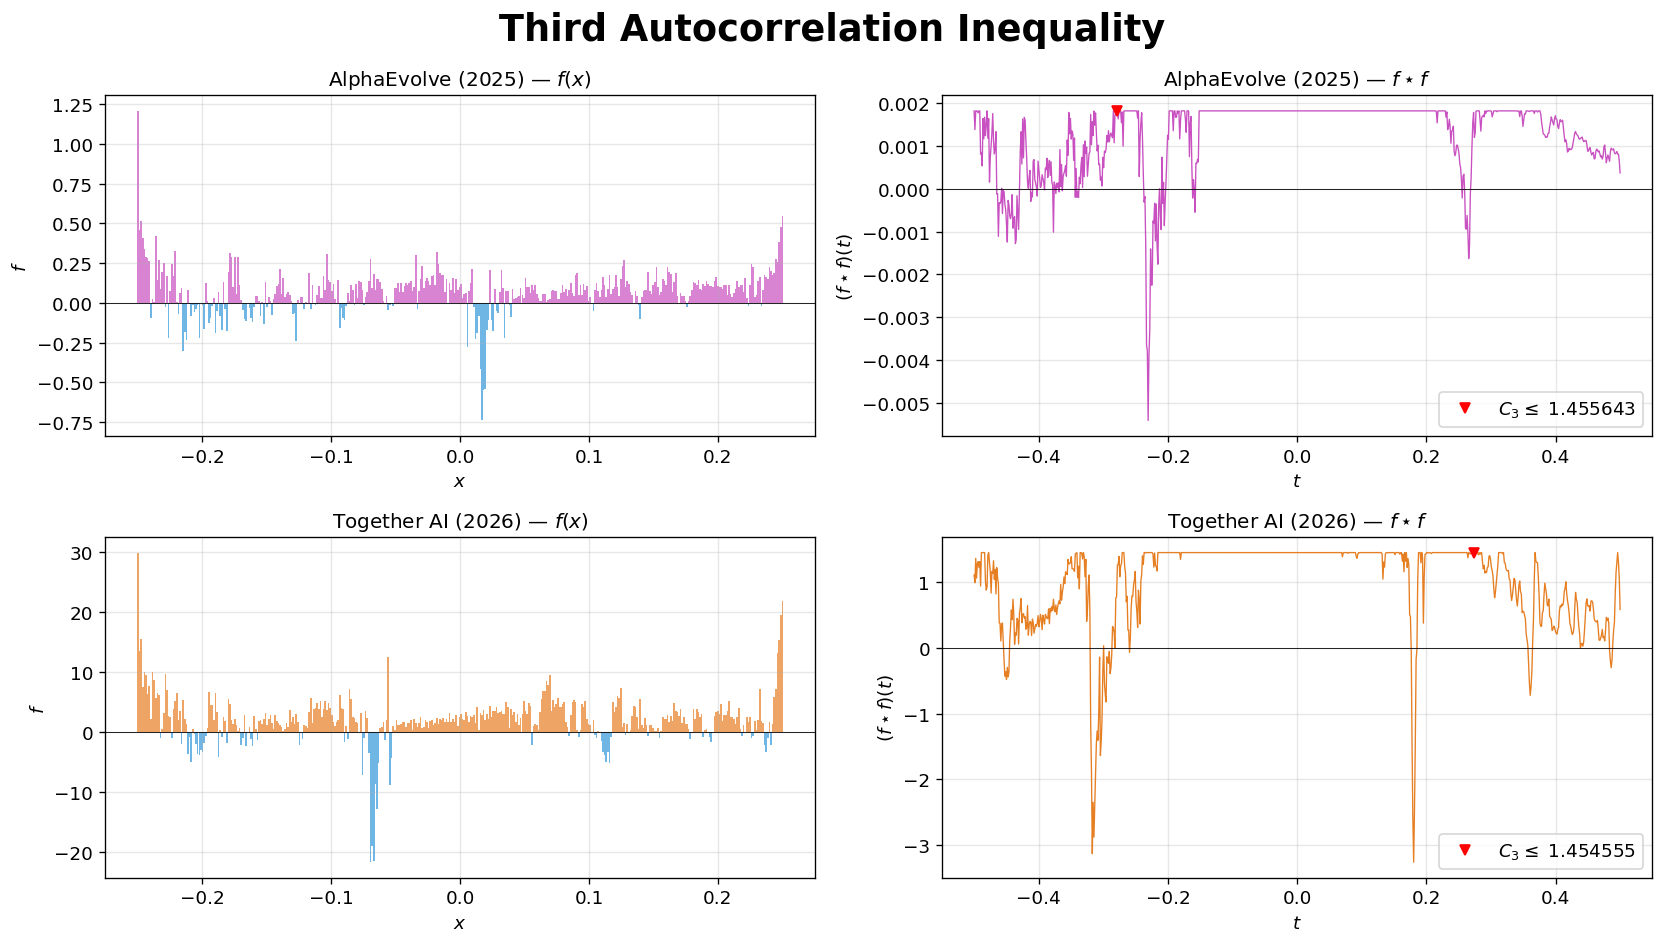

In [8]:
colors = ['#C850C0', '#E67E22']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for idx, ((name, vals), color) in enumerate(zip(solutions, colors)):
    f = np.array(vals, dtype=np.float64)
    n = len(f)
    dx = 0.5 / n

    ax = axes[idx, 0]
    x_f = np.linspace(-0.25, 0.25, n)
    ax.bar(x_f, f, width=dx, color=np.where(f >= 0, color, '#3498DB'), alpha=0.7, edgecolor='none')
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_title(f'{name} — $f(x)$', fontsize=12)
    ax.set_xlabel('$x$')
    ax.set_ylabel('$f$')
    ax.grid(True, alpha=0.3)

    ax = axes[idx, 1]
    conv = np.convolve(f, f, mode='full') * dx
    x_conv = np.linspace(-0.5, 0.5, len(conv))
    ax.plot(x_conv, conv, color=color, linewidth=0.8)
    ax.axhline(0, color='black', linewidth=0.5)
    peak_idx = np.argmax(conv)
    ax.plot(x_conv[peak_idx], conv[peak_idx], 'rv', markersize=6,
            label=f'$C_3 \\leq$ {scores[name]:.6f}')
    ax.set_title(f'{name} — $f \\star f$', fontsize=12)
    ax.set_xlabel('$t$')
    ax.set_ylabel('$(f \\star f)(t)$')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Third Autocorrelation Inequality", fontsize=22, fontweight='bold')
plt.tight_layout()
plt.show()